# MOLTIE – Prework Cell (Y Summary + JSONL Flatten)

## Purpose

This notebook cell performs **two prep steps** before deeper Moltie analysis:

1. **Summarise `Y_inferred.json`**: which WS rows produced a valid `Y` and which `X` tests were emitted.
2. **Flatten `MASTER_moltie.jsonl`** into tabular form and build a **PDF hit frequency** view.

It then saves both flattened outputs as CSVs next to the master JSONL file.

---

## Inputs

### Files

* `Y_inferred.json`

  * Path: `/home/hello/Projects/Statements/output/Y_inferred.json`
  * Expected to contain a `rows` object keyed by `y_row_id`.

* `MASTER_moltie.jsonl`

  * Path: `/home/hello/Projects/Statements/output/moltie_batch/MASTER_moltie.jsonl`

* `flatter.py`

  * Dir: `/home/hello/Projects/Statements/code/data_analysis`
  * Must export:

    * `flatten_moltie_jsonl(jsonl_path)`
    * `pdf_hit_frequency_view(df_flat)`

### Python deps

* `pandas`

---

## What it Produces

### 1) `y_summary_df`

A per-WS-row summary table:

* `y_row_id`: key from `Y_inferred.json: rows`
* `row_index_1based`: 1-based WS row index
* `y_ok`: whether inference succeeded for that row
* `n_x_tests`: number of `X*` tests emitted (only if `y_ok=True`)
* `x_keys`: list of X test keys (e.g. `['X5', 'X12']`)

Also prints:

* total Y rows
* count of `y_ok` vs `y_fail`

### 2) `df_flat`

Flattened table output from `MASTER_moltie.jsonl` (schema defined by `flatter.py`).

### 3) `df_pdf_freq`

Aggregated PDF-level frequency view computed from `df_flat`.

---

## Output Files

Saved next to `MASTER_moltie.jsonl`:

* `MASTER_moltie__flat.csv`
* `MASTER_moltie__pdf_frequency.csv`

(Implemented by stripping `.jsonl` then appending `__flat.csv` and `__pdf_frequency.csv`.)

---

## Execution Flow

1. **Validate input paths** with `assert`.
2. **Load Y JSON** and build `y_summary_df`:

   * Only extracts `x_tests` when `y_ok=True`.
3. **Import flatteners** by adding `FLATTER_DIR` to `sys.path`.
4. **Generate outputs**:

   * `df_flat = flatten_moltie_jsonl(JSONL_PATH)`
   * `df_pdf_freq = pdf_hit_frequency_view(df_flat)`
5. **Save CSVs** and display:

   * `df_flat.head(10)`
   * `df_pdf_freq.head(20)`

---

## Notes / Assumptions

* `Y_inferred.json` must have structure: `{'rows': {<y_row_id>: {...}}}`.
* `x_tests` is expected to be a dict; if not, it is ignored.
* `display(...)` assumes a Jupyter environment.


In [1]:
import json
import sys
from pathlib import Path

import pandas as pd

# =========================================================
# PREWORK (Y + MOLTIE FLATTEN)
# 1) Summarise Y_inferred.json (which WS rows produced Y + which Xs)
# 2) Load MASTER_moltie.jsonl -> flatten to df_flat
# 3) Build pdf frequency view -> df_pdf_freq
# 4) Save both CSVs next to MASTER jsonl
# =========================================================

# -------------------------
# PATHS
# -------------------------
Y_PATH = Path("/home/hello/Projects/Statements/output/Y_inferred.json")
JSONL_PATH = Path("output/moltie_batch/batch_results_BATCH_mode_offensive_Y_manual_debug_0001_20260424_115753.jsonl")
FLATTER_DIR = Path("/home/hello/Projects/Statements/code/data_analysis")  # contains flatter.py

assert Y_PATH.exists(), f"Missing: {Y_PATH}"
assert JSONL_PATH.exists(), f"Missing: {JSONL_PATH}"
assert (FLATTER_DIR / "flatter.py").exists(), f"Missing: {FLATTER_DIR/'flatter.py'}"

# -------------------------
# 1) Y SUMMARY (rows -> X-tests)
# -------------------------
with Y_PATH.open("r", encoding="utf-8") as f:
    y_data = json.load(f)

rows = y_data.get("rows", {})

records = []
for y_row_id, row_data in rows.items():
    y_ok = bool(row_data.get("y_ok", False))
    row_index = row_data.get("row_index_1based")

    x_keys = []
    if y_ok:
        y_block = row_data.get("y") or {}
        x_tests = y_block.get("x_tests") or {}
        if isinstance(x_tests, dict):
            x_keys = list(x_tests.keys())

    records.append({
        "y_row_id": y_row_id,
        "row_index_1based": row_index,
        "y_ok": y_ok,
        "n_x_tests": len(x_keys),
        "x_keys": x_keys,
    })

y_summary_df = (
    pd.DataFrame(records)
      .sort_values("row_index_1based", na_position="last")
      .reset_index(drop=True)
)

print("Y rows:", len(y_summary_df), "| y_ok:", int(y_summary_df["y_ok"].sum()), "| y_fail:", int((~y_summary_df["y_ok"]).sum()))
display(y_summary_df)

# -------------------------
# 2) Import flatter.py + build flat outputs
# -------------------------
if str(FLATTER_DIR) not in sys.path:
    sys.path.append(str(FLATTER_DIR))

from flatter import flatten_moltie_jsonl, pdf_hit_frequency_view  # noqa: E402

df_flat = flatten_moltie_jsonl(JSONL_PATH)
df_pdf_freq = pdf_hit_frequency_view(df_flat)

print("df_flat shape:", df_flat.shape)
print("df_pdf_freq shape:", df_pdf_freq.shape)

# -------------------------
# 3) Save next to MASTER jsonl
# -------------------------
BASE = JSONL_PATH.with_suffix("")  # remove .jsonl
CSV_FLAT = BASE.with_name(BASE.name + "__flat.csv")
CSV_PDF_FREQ = BASE.with_name(BASE.name + "__pdf_frequency.csv")

df_flat.to_csv(CSV_FLAT, index=False)
df_pdf_freq.to_csv(CSV_PDF_FREQ, index=False)

print("Saved flat:", CSV_FLAT)
print("Saved pdf frequency:", CSV_PDF_FREQ)


import pandas as pd
from pathlib import Path

def build_precedent_excel(df_flat: pd.DataFrame, output_path: Path):
    """
    Creates an Excel file with:
    - Sheet 1: filtered rows (precedent_score > 0)
    - Sheet 2: aggregated stats by doc_id, including PDF path metadata

    Main ranking logic is based on X richness adjusted by precedent strength.

    Expected useful columns in df_flat:
    - doc_id
    - precedent_score
    - confidence
    - anchor_count
    - matched_X_count
    - et_path (preferred)
    - et_filename (optional but recommended)
    """

    # -------------------------
    # Validate required columns
    # -------------------------
    required_cols = ["doc_id", "precedent_score"]
    missing = [c for c in required_cols if c not in df_flat.columns]
    if missing:
        raise ValueError(f"Missing required columns in df_flat: {missing}")

    # -------------------------
    # Sheet 1: Filtered signal
    # -------------------------
    df_signal = df_flat[df_flat["precedent_score"] > 0].copy()

    # Defensive numeric coercion
    numeric_cols = [
        "precedent_score",
        "confidence",
        "anchor_count",
        "matched_X_count",
    ]
    for col in numeric_cols:
        if col in df_signal.columns:
            df_signal[col] = pd.to_numeric(df_signal[col], errors="coerce")

    # Fill numeric nulls after coercion
    if "precedent_score" in df_signal.columns:
        df_signal["precedent_score"] = df_signal["precedent_score"].fillna(0)

    if "confidence" in df_signal.columns:
        df_signal["confidence"] = df_signal["confidence"].fillna(0)

    if "anchor_count" in df_signal.columns:
        df_signal["anchor_count"] = df_signal["anchor_count"].fillna(0)

    if "matched_X_count" in df_signal.columns:
        df_signal["matched_X_count"] = df_signal["matched_X_count"].fillna(0)
    else:
        df_signal["matched_X_count"] = 0

    # -------------------------
    # Add weighted X score
    # -------------------------
    df_signal["x_weighted_score"] = (
        df_signal["precedent_score"] * df_signal["matched_X_count"]
    )

    # -------------------------
    # Helper for first valid value
    # -------------------------
    def first_valid(series):
        s = series.dropna().astype(str)
        s = s[s.str.strip() != ""]
        return s.iloc[0] if not s.empty else None

    # -------------------------
    # Build aggregation spec
    # -------------------------
    agg_spec = {
        "precedent_avg": ("precedent_score", "mean"),
        "precedent_sum": ("precedent_score", "sum"),
        "confidence_avg": ("confidence", "mean"),
        "anchor_sum": ("anchor_count", "sum"),
        "x_count_sum": ("matched_X_count", "sum"),
        "x_weighted_score": ("x_weighted_score", "sum"),
    }

    # Optional audit metric only
    agg_spec["n_matches"] = ("doc_id", "count")

    # Carry path metadata if available
    if "et_path" in df_signal.columns:
        agg_spec["et_path"] = ("et_path", first_valid)

    if "et_filename" in df_signal.columns:
        agg_spec["et_filename"] = ("et_filename", first_valid)
    elif "et_path" in df_signal.columns:
        # derive filename from path if filename column not present
        def first_filename_from_path(series):
            path_val = first_valid(series)
            if path_val is None:
                return None
            return Path(path_val).name

        agg_spec["et_filename"] = ("et_path", first_filename_from_path)

    # -------------------------
    # Sheet 2: Aggregation by PDF
    # -------------------------
    df_agg = (
        df_signal
        .groupby("doc_id", dropna=False)
        .agg(**agg_spec)
        .reset_index()
    )

    # -------------------------
    # Readability formatting
    # -------------------------
    round_cols = [
        "precedent_avg",
        "precedent_sum",
        "confidence_avg",
        "x_weighted_score",
    ]
    for col in round_cols:
        if col in df_agg.columns:
            df_agg[col] = df_agg[col].round(2)

    # Useful density metric
    if "n_matches" in df_agg.columns:
        df_agg["x_per_match"] = (
            df_agg["x_count_sum"] / df_agg["n_matches"].replace(0, pd.NA)
        ).round(2)

    # -------------------------
    # Sort: strongest first
    # Main ranking now prioritises weighted X richness
    # -------------------------
    sort_cols = ["x_weighted_score", "precedent_avg", "x_count_sum", "anchor_sum"]
    sort_cols = [c for c in sort_cols if c in df_agg.columns]

    df_agg = df_agg.sort_values(
        by=sort_cols,
        ascending=[False] * len(sort_cols),
        na_position="last"
    ).reset_index(drop=True)

    # -------------------------
    # Save Excel
    # -------------------------
    with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
        df_signal.to_excel(writer, sheet_name="filtered_rows", index=False)
        df_agg.to_excel(writer, sheet_name="pdf_aggregation", index=False)

    print(f"Saved Excel to: {output_path}")

    included_cols = [c for c in ["et_path", "et_filename", "x_weighted_score"] if c in df_agg.columns]
    if included_cols:
        print(f"Included aggregated helper columns: {included_cols}")

# Example usage:
OUTPUT_EXCEL = JSONL_PATH.with_name(JSONL_PATH.stem + "__precedent_analysis.xlsx")
build_precedent_excel(df_flat, OUTPUT_EXCEL)

Y rows: 12 | y_ok: 10 | y_fail: 2


,y_row_id,row_index_1based,y_ok,n_x_tests,x_keys
0,X1_0001,1,False,0,[]
1,X1_0002,2,True,7,"[X1, X2, X3, X4, X5, X6, X7]"
2,X1_0003,3,True,5,"[X1, X2, X3, X4, X5]"
3,X1_0004,4,True,5,"[X1, X2, X3, X4, X5]"
4,X1_0005,5,True,5,"[X1, X2, X3, X4, X5]"
5,X1_0006,6,True,7,"[X1, X2, X3, X4, X5, X6, X7]"
6,X1_0007,7,True,7,"[X1, X2, X3, X4, X5, X6, X7]"
7,X1_0008,8,False,0,[]
8,X1_0009,9,True,4,"[X1, X2, X3, X4]"
9,X1_0010,10,True,7,"[X1, X2, X3, X4, X5, X6, X7]"


df_flat shape: (1050, 31)
df_pdf_freq shape: (41, 15)
Saved flat: output/moltie_batch/batch_results_BATCH_mode_offensive_Y_manual_debug_0001_20260424_115753__flat.csv
Saved pdf frequency: output/moltie_batch/batch_results_BATCH_mode_offensive_Y_manual_debug_0001_20260424_115753__pdf_frequency.csv
Saved Excel to: output/moltie_batch/batch_results_BATCH_mode_offensive_Y_manual_debug_0001_20260424_115753__precedent_analysis.xlsx
Included aggregated helper columns: ['et_path', 'et_filename', 'x_weighted_score']


/home/hello/Projects/Statements/code/data_analysis/flatter.py:455: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  piped = g.apply(


# MOLTIE – Prework Cell (Y Summary + JSONL Flatten)

## Purpose

This notebook cell performs **two prep steps** before deeper Moltie analysis:

1. **Summarise `Y_inferred.json`**: which WS rows produced a valid `Y` and which `X` tests were emitted.
2. **Flatten `MASTER_moltie.jsonl`** into tabular form and build a **PDF hit frequency** view.

It then saves both flattened outputs as CSVs next to the master JSONL file.

---

## Inputs

### Files

* `Y_inferred.json`

  * Path: `/home/hello/Projects/Statements/output/Y_inferred.json`
  * Expected to contain a `rows` object keyed by `y_row_id`.

* `MASTER_moltie.jsonl`

  * Path: `/home/hello/Projects/Statements/output/moltie_batch/MASTER_moltie.jsonl`

* `flatter.py`

  * Dir: `/home/hello/Projects/Statements/code/data_analysis`
  * Must export:

    * `flatten_moltie_jsonl(jsonl_path)`
    * `pdf_hit_frequency_view(df_flat)`

### Python deps

* `pandas`

---

## What it Produces

### 1) `y_summary_df`

A per-WS-row summary table:

* `y_row_id`: key from `Y_inferred.json: rows`
* `row_index_1based`: 1-based WS row index
* `y_ok`: whether inference succeeded for that row
* `n_x_tests`: number of `X*` tests emitted (only if `y_ok=True`)
* `x_keys`: list of X test keys (e.g. `['X5', 'X12']`)

Also prints:

* total Y rows
* count of `y_ok` vs `y_fail`

### 2) `df_flat`

Flattened table output from `MASTER_moltie.jsonl` (schema defined by `flatter.py`).

### 3) `df_pdf_freq`

Aggregated PDF-level frequency view computed from `df_flat`.

---

## Output Files

Saved next to `MASTER_moltie.jsonl`:

* `MASTER_moltie__flat.csv`
* `MASTER_moltie__pdf_frequency.csv`

(Implemented by stripping `.jsonl` then appending `__flat.csv` and `__pdf_frequency.csv`.)

---

## Execution Flow

1. **Validate input paths** with `assert`.
2. **Load Y JSON** and build `y_summary_df`:

   * Only extracts `x_tests` when `y_ok=True`.
3. **Import flatteners** by adding `FLATTER_DIR` to `sys.path`.
4. **Generate outputs**:

   * `df_flat = flatten_moltie_jsonl(JSONL_PATH)`
   * `df_pdf_freq = pdf_hit_frequency_view(df_flat)`
5. **Save CSVs** and display:

   * `df_flat.head(10)`
   * `df_pdf_freq.head(20)`

---

## Notes / Assumptions

* `Y_inferred.json` must have structure: `{'rows': {<y_row_id>: {...}}}`.
* `x_tests` is expected to be a dict; if not, it is ignored.
* `display(...)` assumes a Jupyter environment.

---

# MOLTIE – WS ↔ Moltie Relevance Alignment Cell

## Purpose

This cell aligns:

* **Witness Statement enhanced CSV** (`Leonardo_WS_enhanced.csv`)
* **Moltie flattened output** (`df_flat` from `flatten_moltie_jsonl`)

It classifies each WS row into buckets based on:

1. Whether the WS row hit any needle.
2. Whether Moltie found at least one **relevant** case for that row.

---

## Preconditions

* `df_flat` must already exist in memory.
* `df_flat` must contain at least:

  * `y_row_id`
  * `relevant`

---

## Step 1 – Load WS Enhanced CSV

Input:
`/home/hello/Projects/Statements/output/Leonardo_WS_enhanced.csv`

Prints shape for validation.

---

## Step 2 – Ensure `y_row_id`

Priority order:

1. Use existing `y_row_id` column.
2. Else derive from:

   * `row_id`
   * or `X1`
   * or fallback to 1-based row order.

Derived format:

```
X1_0001
X1_0002
...
```

---

## Step 3 – Detect WS Needle Hits

Creates `ws_has_any_needle` using:

Priority:

1. `has__any_needle`
2. `needle_selected_raw`
3. Any column starting with `has__`

If none found → raises error.

---

## Step 4 – Compute Moltie Relevance by Row

From `df_flat`:

* Force `relevant` to boolean.
* Group by `y_row_id`.
* Compute:

```
has_relevant_case = any(relevant == True)
```

Result: one row per `y_row_id`.

---

## Step 5 – Join + Bucket Classification

Merge WS-level view with Moltie relevance.

Each row classified into:

* `NEEDLE_AND_RELEVANT`
* `NEEDLE_BUT_NO_RELEVANT`
* `NO_NEEDLE`

Logic:

* No WS needle → `NO_NEEDLE`
* Needle + relevant case → `NEEDLE_AND_RELEVANT`
* Needle + no relevant case → `NEEDLE_BUT_NO_RELEVANT`

---

## Step 6 – Frequency Table

Produces:

| bucket | count | pct |

With stable ordering:

1. `NEEDLE_AND_RELEVANT`
2. `NEEDLE_BUT_NO_RELEVANT`
3. `NO_NEEDLE`

Also displays first 50 classified rows for QA.

---

## Interpretation

This table answers:

* Are WS needles actually finding precedent support?
* Where do we have needle hits but no relevant Moltie match?
* Where are we completely blind (no needle)?

This is the integrity bridge between:

**WS Enhanced → Needle Logic → Moltie → Precedent Relevance**

---

# MOLTIE – X Metrics + Mostly‑Noise Triage (Single Cell)

## Purpose

Build a single aggregated table (`x_metrics`) that measures how well each **(WS row, X-test)** performs across all ET documents, then derive a second table (`bad`) that flags **mostly-noise** combinations (high run volume, low relevance rate).

## Inputs

* `df_flat` (from `flatten_moltie_jsonl`) with at least:

  * `y_row_id`, `x_key`, `x_name`, `et_path`, `relevant`, `confidence`

## Outputs

* `x_metrics`: one row per (`y_row_id`, `x_key`, `x_name`) with:

  * `total_runs`, `n_relevant`, `relevant_rate_pct`, plus max signal fields.
  * Sorted to show strongest performers first.
* `bad`: subset of `x_metrics` where:

  * `total_runs >= MIN_RUNS` and `relevant_rate_pct <= MAX_RATE_PCT`
  * Includes `bad_score` to prioritise the most expensive low‑yield pairs.

## What it prints/displays

* Top 50 rows of `x_metrics`
* Counts: universe size + mostly‑noise row count
* Top 50 rows of `bad`


In [2]:
import numpy as np
import pandas as pd

# =========================================================
# IMPROVED X METRICS + GLOBAL NOISE TRIAGE
# Main diagnostic cell for MOLTIE signal quality
# =========================================================

assert "df_flat" in globals(), "df_flat not found. Run flatten_moltie_jsonl first."

# -------------------------
# CONFIG: signal thresholds
# -------------------------
MIN_PRECEDENT_SCORE = 50
MIN_CONFIDENCE = 60
MIN_RUNS_GLOBAL = 10
MAX_RATE_PCT_GLOBAL = 10.0   # <= 10% strong-hit rate = mostly noise

# -------------------------
# 1) PREP / NORMALISE
# -------------------------
m = df_flat.copy()

# Defensive numeric coercion
numeric_cols = ["confidence", "precedent_score", "anchor_count", "matched_X_count"]
for col in numeric_cols:
    if col in m.columns:
        m[col] = pd.to_numeric(m[col], errors="coerce")

# Normalize relevant
m["relevant_bool"] = m["relevant"] == True

# Strong hit = actual useful signal
m["strong_hit"] = (
    m["relevant_bool"] &
    (m["precedent_score"].fillna(0) >= MIN_PRECEDENT_SCORE) &
    (m["confidence"].fillna(0) >= MIN_CONFIDENCE)
)

# Weak hit = marked relevant upstream, but fails strong thresholds
m["weak_hit"] = m["relevant_bool"] & (~m["strong_hit"])

# Convenience columns
m["anchor_count"] = m["anchor_count"].fillna(0)
m["matched_X_count"] = m["matched_X_count"].fillna(0)
m["confidence"] = m["confidence"].fillna(0)
m["precedent_score"] = m["precedent_score"].fillna(0)

# Optional fallback labels if x_name missing
if "x_name" not in m.columns:
    m["x_name"] = None
if "x_key" not in m.columns:
    raise ValueError("df_flat must contain x_key for X-surface diagnostics.")

# -------------------------
# 2) LOCAL X METRICS
# one row per WS row + X test
# -------------------------
x_metrics_local = (
    m.groupby(["y_row_id", "x_key", "x_name"], dropna=False)
     .agg(
         total_runs=("x_key", "size"),
         n_strong=("strong_hit", "sum"),
         n_weak=("weak_hit", "sum"),
         n_relevant_raw=("relevant_bool", "sum"),
         mean_confidence=("confidence", "mean"),
         max_confidence=("confidence", "max"),
         mean_precedent_score=("precedent_score", "mean"),
         max_precedent_score=("precedent_score", "max"),
         anchor_sum=("anchor_count", "sum"),
         max_anchor_count=("anchor_count", "max"),
         matched_X_sum=("matched_X_count", "sum"),
         n_unique_docs=("doc_id", "nunique"),
     )
     .reset_index()
)

x_metrics_local["strong_rate_pct"] = (
    x_metrics_local["n_strong"] / x_metrics_local["total_runs"] * 100
).round(2)

x_metrics_local["raw_relevant_rate_pct"] = (
    x_metrics_local["n_relevant_raw"] / x_metrics_local["total_runs"] * 100
).round(2)

x_metrics_local = x_metrics_local.sort_values(
    by=["strong_rate_pct", "n_strong", "mean_precedent_score", "max_precedent_score"],
    ascending=[False, False, False, False],
    na_position="last"
).reset_index(drop=True)

print("LOCAL X METRICS")
print("Rows:", len(x_metrics_local))
display(x_metrics_local.head(50))

# -------------------------
# 3) GLOBAL X METRICS
# one row per X surface across the whole pipeline
# -------------------------
x_metrics_global = (
    m.groupby(["x_key", "x_name"], dropna=False)
     .agg(
         total_runs=("x_key", "size"),
         n_strong=("strong_hit", "sum"),
         n_weak=("weak_hit", "sum"),
         n_relevant_raw=("relevant_bool", "sum"),
         mean_confidence=("confidence", "mean"),
         max_confidence=("confidence", "max"),
         mean_precedent_score=("precedent_score", "mean"),
         max_precedent_score=("precedent_score", "max"),
         anchor_sum=("anchor_count", "sum"),
         max_anchor_count=("anchor_count", "max"),
         matched_X_sum=("matched_X_count", "sum"),
         n_unique_docs=("doc_id", "nunique"),
         n_unique_rows=("y_row_id", "nunique"),
     )
     .reset_index()
)

x_metrics_global["strong_rate_pct"] = (
    x_metrics_global["n_strong"] / x_metrics_global["total_runs"] * 100
).round(2)

x_metrics_global["raw_relevant_rate_pct"] = (
    x_metrics_global["n_relevant_raw"] / x_metrics_global["total_runs"] * 100
).round(2)

x_metrics_global = x_metrics_global.sort_values(
    by=["strong_rate_pct", "n_strong", "mean_precedent_score", "total_runs"],
    ascending=[False, False, False, False],
    na_position="last"
).reset_index(drop=True)

print("GLOBAL X METRICS")
print("Rows:", len(x_metrics_global))
display(x_metrics_global.head(50))

# -------------------------
# 4) GLOBAL MOSTLY-NOISE TRIAGE
# target: X surfaces that fire a lot but rarely produce strong signal
# -------------------------
bad_global = x_metrics_global[
    (x_metrics_global["total_runs"] >= MIN_RUNS_GLOBAL) &
    (x_metrics_global["strong_rate_pct"] <= MAX_RATE_PCT_GLOBAL)
].copy()

# Confidence-scaled noise score:
# - more runs = worse
# - lower strong-hit rate = worse
# - higher confidence when wrong = worse
# - weak hits add penalty because they look superficially relevant upstream
conf01 = (bad_global["mean_confidence"].fillna(0) / 100.0).clip(0, 1)
weak_ratio = (bad_global["n_weak"] / bad_global["total_runs"]).fillna(0)

bad_global["bad_score"] = (
    np.log1p(bad_global["total_runs"]) *
    (1 - bad_global["strong_rate_pct"] / 100.0) *
    (1 + 0.6 * conf01) *
    (1 + 0.5 * weak_ratio)
)

bad_global = bad_global.sort_values(
    by=["bad_score", "total_runs", "strong_rate_pct"],
    ascending=[False, False, True],
    na_position="last"
).reset_index(drop=True)

print("GLOBAL MOSTLY-NOISE X SURFACES")
print("Rows:", len(bad_global))
display(bad_global.head(50))

# -------------------------
# 5) OPTIONAL: GLOBAL GOOD SURFACES
# target: X surfaces that repeatedly produce strong signal
# -------------------------
good_global = x_metrics_global[
    (x_metrics_global["n_strong"] > 0)
].copy()

good_global["good_score"] = (
    np.log1p(good_global["n_strong"]) *
    (good_global["strong_rate_pct"] / 100.0) *
    (1 + 0.4 * (good_global["mean_precedent_score"] / 100.0).clip(0, 1)) *
    (1 + 0.2 * (good_global["anchor_sum"] / good_global["total_runs"]).fillna(0))
)

good_global = good_global.sort_values(
    by=["good_score", "n_strong", "strong_rate_pct", "mean_precedent_score"],
    ascending=[False, False, False, False],
    na_position="last"
).reset_index(drop=True)

print("GLOBAL GOOD X SURFACES")
print("Rows:", len(good_global))
display(good_global.head(50))

LOCAL X METRICS
Rows: 21


,y_row_id,x_key,x_name,total_runs,n_strong,n_weak,n_relevant_raw,mean_confidence,max_confidence,mean_precedent_score,max_precedent_score,anchor_sum,max_anchor_count,matched_X_sum,n_unique_docs,strong_rate_pct,raw_relevant_rate_pct
0,MANUAL_DEBUG_0001,X17,Unsupported Alleged Instruction or Weak Factua...,50,28,0,28,44.2,80.0,39.0,80.0,33,2,28,50,56.0,56.0
1,MANUAL_DEBUG_0001,X18,Disproportionate Outcome or Comparator Inconsi...,50,15,0,15,24.0,80.0,21.2,80.0,15,1,15,50,30.0,30.0
2,MANUAL_DEBUG_0001,X9,Contemporaneous Communications Support the Emp...,50,15,0,15,24.0,80.0,21.0,70.0,17,2,15,50,30.0,30.0
3,MANUAL_DEBUG_0001,X6,Procedural Preparation Rights Denied,50,14,0,14,22.2,80.0,19.4,70.0,16,2,14,50,28.0,28.0
4,MANUAL_DEBUG_0001,X12,Unsupported or Internally Inconsistent Reasoning,50,13,0,13,20.9,85.0,18.4,80.0,14,2,13,50,26.0,26.0
5,MANUAL_DEBUG_0001,X14,Breach of Confidentiality or Premature Dissemi...,50,11,0,11,17.7,85.0,16.0,80.0,14,2,11,50,22.0,22.0
6,MANUAL_DEBUG_0001,X7,Defence Presented but Not Properly Engaged,50,10,0,10,15.6,80.0,14.0,80.0,10,1,10,50,20.0,20.0
7,MANUAL_DEBUG_0001,X16,Failure to Provide Timely or Genuine Appeal Re...,50,10,0,10,16.0,80.0,14.0,70.0,12,2,10,50,20.0,20.0
8,MANUAL_DEBUG_0001,X5,First Disclosure of Allegations at the Meeting,50,9,0,9,14.2,80.0,12.4,70.0,9,1,9,50,18.0,18.0
9,MANUAL_DEBUG_0001,X15,Predetermination or Closed Mind Anchored to Pr...,50,7,0,7,11.3,85.0,10.0,80.0,9,2,7,50,14.0,14.0


GLOBAL X METRICS
Rows: 21


,x_key,x_name,total_runs,n_strong,n_weak,n_relevant_raw,mean_confidence,max_confidence,mean_precedent_score,max_precedent_score,anchor_sum,max_anchor_count,matched_X_sum,n_unique_docs,n_unique_rows,strong_rate_pct,raw_relevant_rate_pct
0,X17,Unsupported Alleged Instruction or Weak Factua...,50,28,0,28,44.2,80.0,39.0,80.0,33,2,28,50,1,56.0,56.0
1,X18,Disproportionate Outcome or Comparator Inconsi...,50,15,0,15,24.0,80.0,21.2,80.0,15,1,15,50,1,30.0,30.0
2,X9,Contemporaneous Communications Support the Emp...,50,15,0,15,24.0,80.0,21.0,70.0,17,2,15,50,1,30.0,30.0
3,X6,Procedural Preparation Rights Denied,50,14,0,14,22.2,80.0,19.4,70.0,16,2,14,50,1,28.0,28.0
4,X12,Unsupported or Internally Inconsistent Reasoning,50,13,0,13,20.9,85.0,18.4,80.0,14,2,13,50,1,26.0,26.0
5,X14,Breach of Confidentiality or Premature Dissemi...,50,11,0,11,17.7,85.0,16.0,80.0,14,2,11,50,1,22.0,22.0
6,X16,Failure to Provide Timely or Genuine Appeal Re...,50,10,0,10,16.0,80.0,14.0,70.0,12,2,10,50,1,20.0,20.0
7,X7,Defence Presented but Not Properly Engaged,50,10,0,10,15.6,80.0,14.0,80.0,10,1,10,50,1,20.0,20.0
8,X5,First Disclosure of Allegations at the Meeting,50,9,0,9,14.2,80.0,12.4,70.0,9,1,9,50,1,18.0,18.0
9,X15,Predetermination or Closed Mind Anchored to Pr...,50,7,0,7,11.3,85.0,10.0,80.0,9,2,7,50,1,14.0,14.0


GLOBAL MOSTLY-NOISE X SURFACES
Rows: 8


,x_key,x_name,total_runs,n_strong,n_weak,n_relevant_raw,mean_confidence,max_confidence,mean_precedent_score,max_precedent_score,anchor_sum,max_anchor_count,matched_X_sum,n_unique_docs,n_unique_rows,strong_rate_pct,raw_relevant_rate_pct,bad_score
0,X22,Unsubstantiated Inference of Intent from Neutr...,50,1,0,1,1.4,70.0,1.2,60.0,1,1,1,50,1,2.0,2.0,3.885556
1,X1,Management-Defined Role Priorities Contradicti...,50,2,0,2,3.2,80.0,2.8,70.0,2,1,2,50,1,4.0,4.0,3.847024
2,X10,Reliance on Undisclosed or Post Hoc LPAD/Data ...,50,2,0,2,3.2,80.0,2.8,70.0,3,2,2,50,1,4.0,4.0,3.847024
3,X8,Reassurance or Closure Representation,50,2,0,2,3.2,80.0,2.8,70.0,2,1,2,50,1,4.0,4.0,3.847024
4,X3,Lack of Prior Instruction or Corrective Guidance,50,3,0,3,4.9,85.0,4.4,80.0,3,1,3,50,1,6.0,6.0,3.804576
5,X11,Misinterpretation or Mischaracterization of Data,50,3,0,3,4.8,80.0,4.2,70.0,3,1,3,50,1,6.0,6.0,3.802358
6,X4,Inadequate Notice of Disciplinary Process,50,3,0,3,4.8,80.0,4.2,70.0,3,1,3,50,1,6.0,6.0,3.802358
7,X21,Delay Inconsistent with Alleged Serious Miscon...,50,3,0,3,4.6,80.0,4.4,80.0,3,1,3,50,1,6.0,6.0,3.797923


GLOBAL GOOD X SURFACES
Rows: 21


,x_key,x_name,total_runs,n_strong,n_weak,n_relevant_raw,mean_confidence,max_confidence,mean_precedent_score,max_precedent_score,anchor_sum,max_anchor_count,matched_X_sum,n_unique_docs,n_unique_rows,strong_rate_pct,raw_relevant_rate_pct,good_score
0,X17,Unsupported Alleged Instruction or Weak Factua...,50,28,0,28,44.2,80.0,39.0,80.0,33,2,28,50,1,56.0,56.0,2.467593
1,X9,Contemporaneous Communications Support the Emp...,50,15,0,15,24.0,80.0,21.0,70.0,17,2,15,50,1,30.0,30.0,0.962958
2,X18,Disproportionate Outcome or Comparator Inconsi...,50,15,0,15,24.0,80.0,21.2,80.0,15,1,15,50,1,30.0,30.0,0.956450
3,X6,Procedural Preparation Rights Denied,50,14,0,14,22.2,80.0,19.4,70.0,16,2,14,50,1,28.0,28.0,0.869389
4,X12,Unsupported or Internally Inconsistent Reasoning,50,13,0,13,20.9,85.0,18.4,80.0,14,2,13,50,1,26.0,26.0,0.777909
5,X14,Breach of Confidentiality or Premature Dissemi...,50,11,0,11,17.7,85.0,16.0,80.0,14,2,11,50,1,22.0,22.0,0.614240
6,X16,Failure to Provide Timely or Genuine Appeal Re...,50,10,0,10,16.0,80.0,14.0,70.0,12,2,10,50,1,20.0,20.0,0.530744
7,X7,Defence Presented but Not Properly Engaged,50,10,0,10,15.6,80.0,14.0,80.0,10,1,10,50,1,20.0,20.0,0.526693
8,X5,First Disclosure of Allegations at the Meeting,50,9,0,9,14.2,80.0,12.4,70.0,9,1,9,50,1,18.0,18.0,0.450684
9,X15,Predetermination or Closed Mind Anchored to Pr...,50,7,0,7,11.3,85.0,10.0,80.0,9,2,7,50,1,14.0,14.0,0.313666


[info] No explicit case-id column found. Using row index as case identifier.
[info] Loaded filtered rows: 41
[info] CSV path: output/moltie_batch/batch_results_BATCH_mode_offensive_Y_manual_debug_0001_20260424_115753__pdf_frequency.csv
[info] Using precedent column: precedent_strength

=== DIVERSITY CHECK ===
[needles] unique=16
[x factors] unique=21

=== NEEDLE TABLE ===


,needle,frequency,weight_sum,avg_strength,case_coverage,weight_share,freq_share
0,has__evidence,41,24.9171,0.607734,41,0.150936,0.157088
1,has__appeal,32,19.9900,0.624688,32,0.121090,0.122605
2,has__role,29,18.2887,0.630645,29,0.110784,0.111111
3,has__investigation,26,16.2774,0.626054,26,0.098601,0.099617
4,has__performance,22,13.6185,0.619023,22,0.082494,0.084291
5,has__grievance,19,12.1487,0.639405,19,0.073591,0.072797
6,has__duties,19,12.0141,0.632321,19,0.072776,0.072797
7,has__procedural_prejudice,18,11.6882,0.649344,18,0.070802,0.068966
8,has__instructions,16,10.0730,0.629563,16,0.061017,0.061303
9,has__disciplinary_hearing,11,7.7850,0.707727,11,0.047158,0.042146



=== TOP X FACTORS (weighted) ===


,x_name,frequency,weight_sum,avg_strength,case_coverage,weight_share,freq_share
0,Unsupported Alleged Instruction or Weak Factua...,28,17.8837,0.638704,28,0.160273,0.164706
1,Disproportionate Outcome or Comparator Inconsi...,15,9.6954,0.646360,15,0.086890,0.088235
2,Contemporaneous Communications Support the Emp...,15,9.4368,0.629120,15,0.084572,0.088235
3,Procedural Preparation Rights Denied,14,9.0175,0.644107,14,0.080814,0.082353
4,Unsupported or Internally Inconsistent Reasoning,13,8.6151,0.662700,13,0.077208,0.076471
5,Breach of Confidentiality or Premature Dissemi...,11,7.3176,0.665236,11,0.065580,0.064706
6,Failure to Provide Timely or Genuine Appeal Re...,10,6.5603,0.656030,10,0.058793,0.058824
7,Defence Presented but Not Properly Engaged,10,6.4780,0.647800,10,0.058056,0.058824
8,First Disclosure of Allegations at the Meeting,9,5.9215,0.657944,9,0.053068,0.052941
9,Predetermination or Closed Mind Anchored to Pr...,7,5.1153,0.730757,7,0.045843,0.041176



=== TOP NEEDLE -> X EDGES (weighted co-occurrence) ===


,needle,x_name,edge_weight,source_total_weight,target_total_weight,edge_weight_norm
0,has__evidence,Unsupported Alleged Instruction or Weak Factua...,17.8837,111.5827,130.1171,0.148420
1,has__appeal,Unsupported Alleged Instruction or Weak Factua...,15.6066,97.3370,130.1171,0.138676
2,has__role,Unsupported Alleged Instruction or Weak Factua...,14.9387,93.5911,130.1171,0.135372
3,has__investigation,Unsupported Alleged Instruction or Weak Factua...,12.3941,83.9534,130.1171,0.118585
4,has__procedural_prejudice,Unsupported Alleged Instruction or Weak Factua...,10.4965,65.0660,130.1171,0.114078
5,has__performance,Unsupported Alleged Instruction or Weak Factua...,10.9435,71.4792,130.1171,0.113475
6,has__role,Contemporaneous Communications Support the Emp...,8.8868,93.5911,70.2352,0.109610
7,has__evidence,Contemporaneous Communications Support the Emp...,9.4368,111.5827,70.2352,0.106598
8,has__evidence,Disproportionate Outcome or Comparator Inconsi...,9.6954,111.5827,74.2369,0.106526
9,has__evidence,Procedural Preparation Rights Denied,9.0175,111.5827,66.5518,0.104642


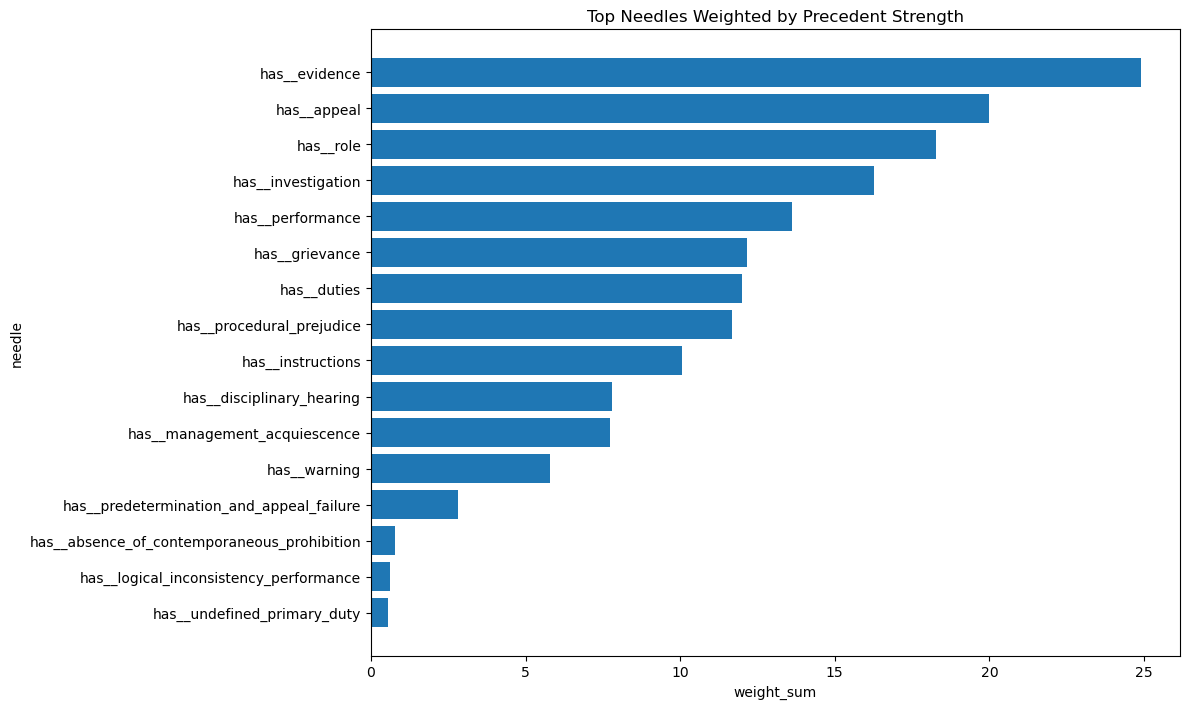

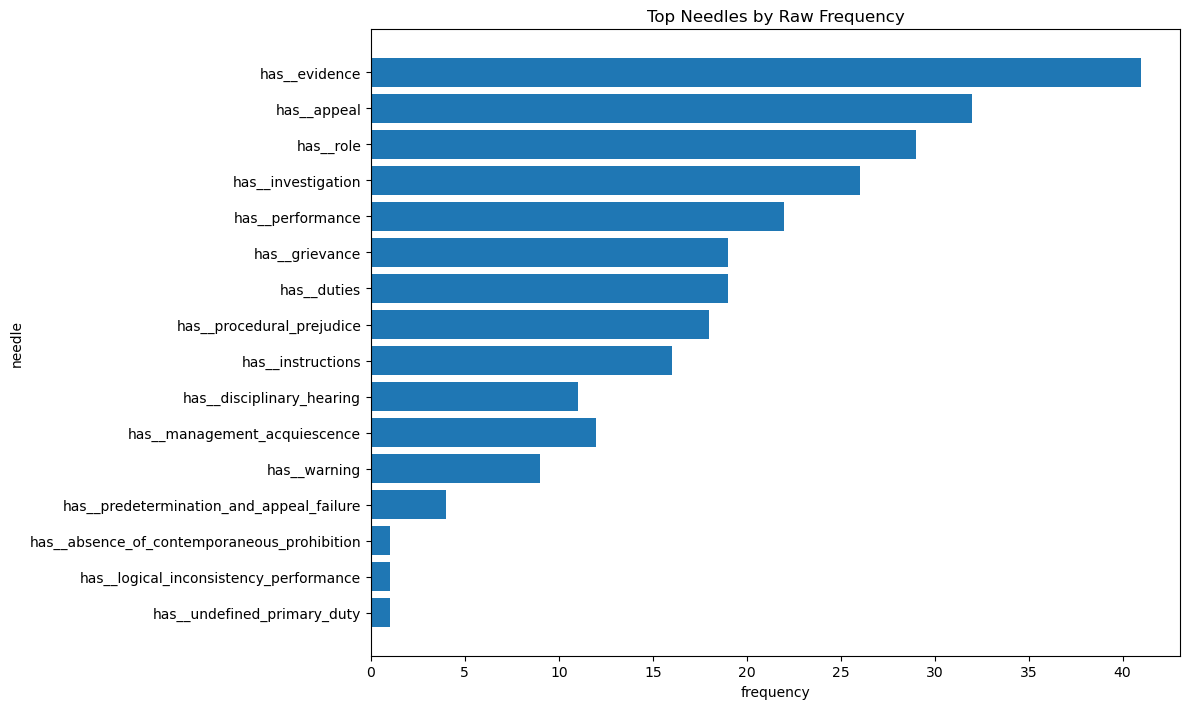

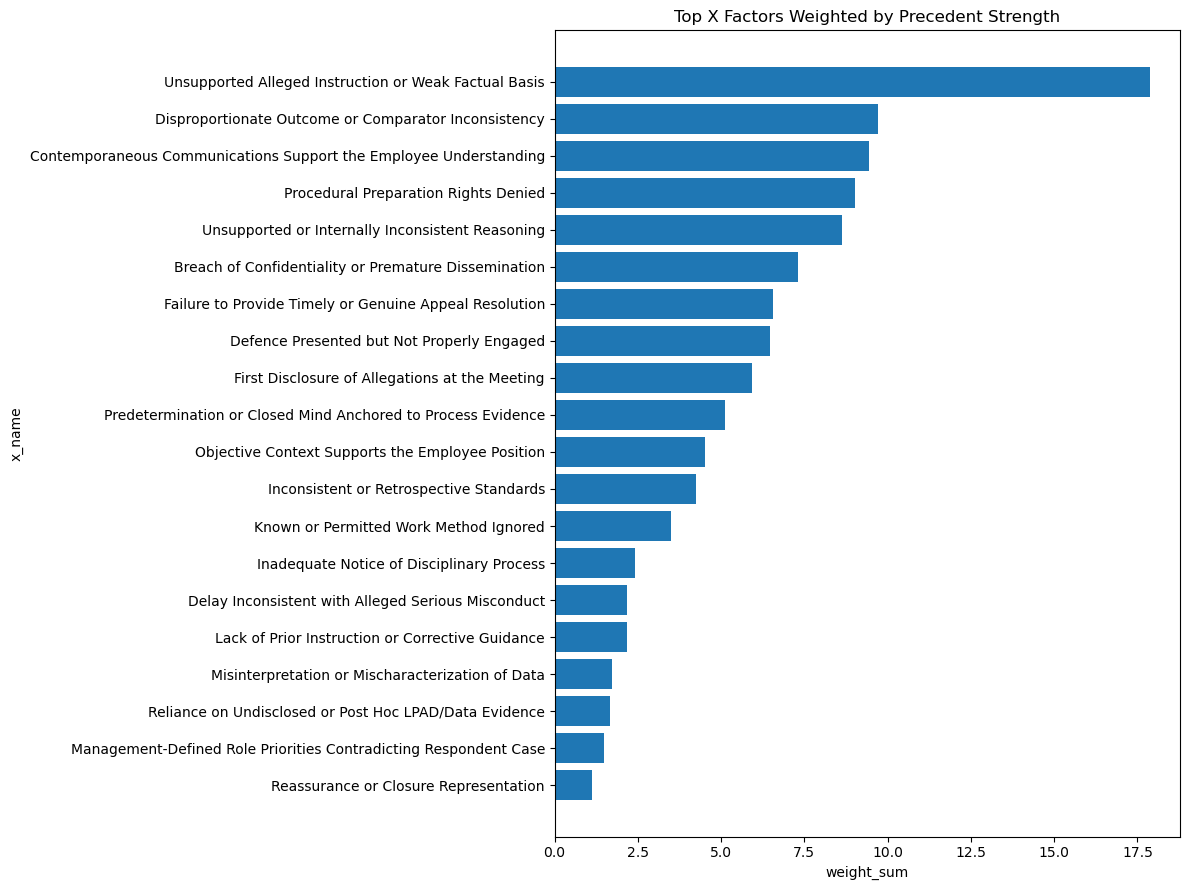

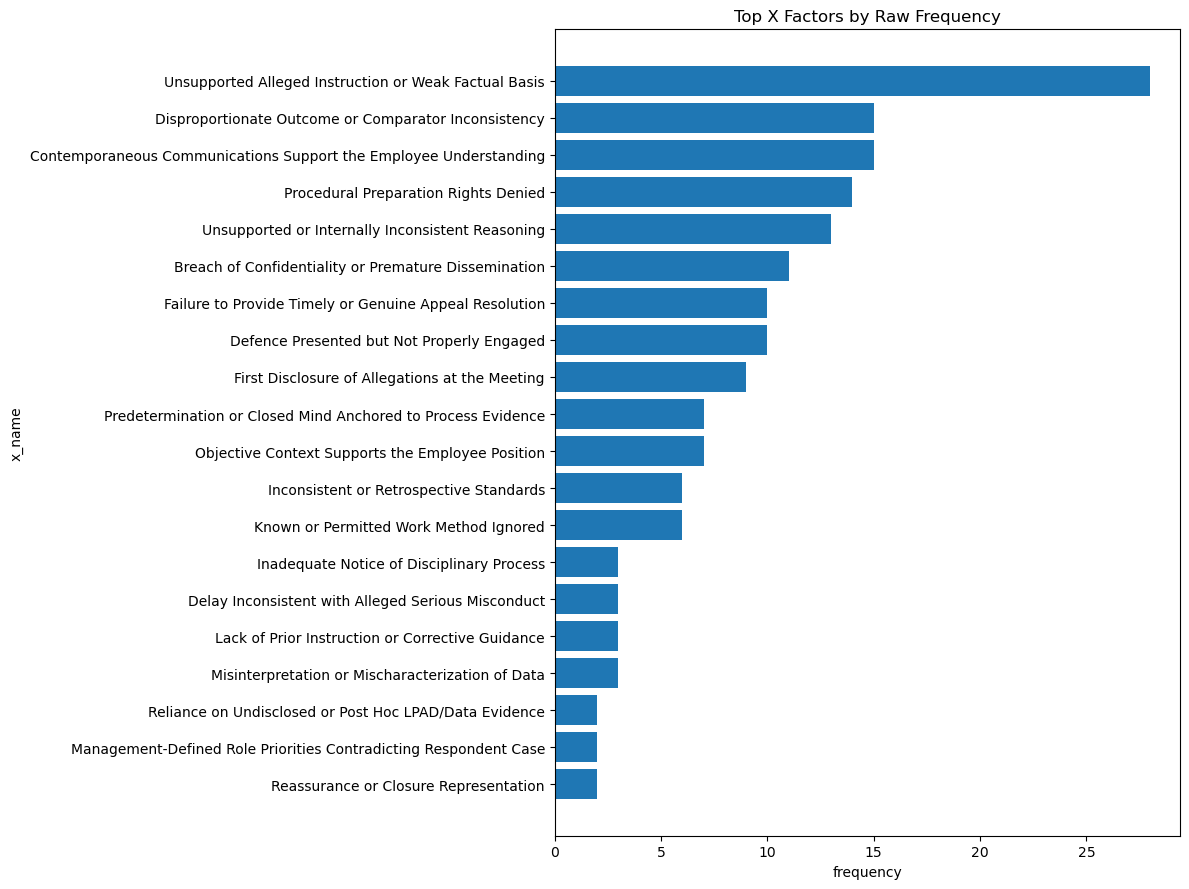


=== QUICK SIGNALS ===
[needle strongest] has__evidence | weight_sum=24.9171, freq=41, avg_strength=0.607734, case_coverage=41
[x strongest] Unsupported Alleged Instruction or Weak Factual Basis | weight_sum=17.8837, freq=28, avg_strength=0.638704, case_coverage=28
[strongest edge] has__evidence -> Unsupported Alleged Instruction or Weak Factual Basis | edge_weight=17.8837, edge_weight_norm=0.14842


In [3]:
# =========================================================
# MOLTIE – Improved Exploratory Needle/X Weighted Frequency Cell
# =========================================================
# Purpose:
#   - Explore matched needles and X factors on a filtered signal layer
#   - Track:
#       1) raw frequency
#       2) precedent-weighted sums
#       3) average precedent strength
#       4) case coverage
#       5) needle ↔ X weighted co-occurrence graph
#   - Avoid pointless charting when needle diversity is too low
#
# Notes:
#   - Exploratory / post-filter cell
#   - Safe against blanks / NaN / odd spacing
#   - Designed to remain useful even if regex arm only yields 1 dominant needle
# =========================================================

from collections import defaultdict
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
CSV_PATH = CSV_PDF_FREQ  # expected aggregated pdf-frequency csv
PRECEDENT_CANDIDATES = ["precedent_strength", "precedent_score", "precedent_avg", "precedent_sum"]
NEEDLE_COL = "matched_needles_pdf"
X_COL = "x_name_pdf"

CASE_ID_CANDIDATES = [
    "doc_id",
    "case_id",
    "case_name",
    "filename",
    "pdf_name",
    "source_file",
    "document_id",
]

TOP_N = 20
SHOW_PLOTS = True

# Optional filtering
MIN_PRECEDENT = 0.0          # keep >0 by default
MIN_CASE_COVERAGE_FOR_CHART = 2
MIN_UNIQUE_NEEDLES_FOR_CHART = 2

# =========================================================
# HELPERS
# =========================================================
def split_pipe_field(value):
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    parts = [p.strip() for p in text.split("|")]
    parts = [p for p in parts if p and p.lower() not in {"nan", "none", "null"}]
    return parts


def choose_first_existing(df, candidates, kind="column"):
    for col in candidates:
        if col in df.columns:
            return col
    raise ValueError(f"No valid {kind} found among: {candidates}")


def choose_case_id_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def build_stats_table(stats_dict, label_col):
    rows = []
    for key, payload in stats_dict.items():
        freq = payload["freq"]
        weight_sum = payload["weight_sum"]
        avg_strength = weight_sum / freq if freq else 0.0
        case_coverage = len(payload["cases"])

        rows.append({
            label_col: key,
            "frequency": freq,
            "weight_sum": round(weight_sum, 6),
            "avg_strength": round(avg_strength, 6),
            "case_coverage": case_coverage,
        })

    out = pd.DataFrame(rows)

    if not out.empty:
        out = out.sort_values(
            ["weight_sum", "frequency", "avg_strength"],
            ascending=[False, False, False]
        ).reset_index(drop=True)

        out["weight_share"] = (out["weight_sum"] / out["weight_sum"].sum()).round(6)
        out["freq_share"] = (out["frequency"] / out["frequency"].sum()).round(6)

    return out


def build_graph_table(graph_dict, source_name="needle", target_name="x_name"):
    rows = []
    for src, targets in graph_dict.items():
        for tgt, weight in targets.items():
            rows.append({
                source_name: src,
                target_name: tgt,
                "edge_weight": round(weight, 6),
            })

    out = pd.DataFrame(rows)

    if not out.empty:
        source_totals = out.groupby(source_name)["edge_weight"].sum()
        target_totals = out.groupby(target_name)["edge_weight"].sum()

        out["source_total_weight"] = out[source_name].map(source_totals)
        out["target_total_weight"] = out[target_name].map(target_totals)

        out["edge_weight_norm"] = (
            out["edge_weight"] /
            np.sqrt(out["source_total_weight"] * out["target_total_weight"])
        ).round(6)

        out = out.sort_values(
            ["edge_weight_norm", "edge_weight"],
            ascending=[False, False]
        ).reset_index(drop=True)

    return out


def plot_top_barh(df_plot, label_col, value_col, title, top_n=20):
    if df_plot.empty:
        print(f"[warn] No data available for plot: {title}")
        return

    data = df_plot.head(top_n).iloc[::-1]
    plt.figure(figsize=(12, max(6, min(12, len(data) * 0.45))))
    plt.barh(data[label_col], data[value_col])
    plt.title(title)
    plt.xlabel(value_col)
    plt.ylabel(label_col)
    plt.tight_layout()
    plt.show()


# =========================================================
# LOAD
# =========================================================
df = pd.read_csv(CSV_PATH)

precedent_col = choose_first_existing(df, PRECEDENT_CANDIDATES, kind="precedent column")
required_cols = [precedent_col, NEEDLE_COL, X_COL]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

case_id_col = choose_case_id_column(df, CASE_ID_CANDIDATES)
if case_id_col is None:
    print("[info] No explicit case-id column found. Using row index as case identifier.")
    df["_row_case_id"] = df.index.astype(str)
    case_id_col = "_row_case_id"
else:
    print(f"[info] Using case identifier column: {case_id_col}")

df[precedent_col] = pd.to_numeric(df[precedent_col], errors="coerce").fillna(0.0)

# Filter weak / empty rows
df = df[df[precedent_col] > MIN_PRECEDENT].copy()

print(f"[info] Loaded filtered rows: {len(df):,}")
print(f"[info] CSV path: {CSV_PATH}")
print(f"[info] Using precedent column: {precedent_col}")

# =========================================================
# EXPLORATORY ACCUMULATORS
# =========================================================
needle_stats = defaultdict(lambda: {"freq": 0, "weight_sum": 0.0, "cases": set()})
x_stats = defaultdict(lambda: {"freq": 0, "weight_sum": 0.0, "cases": set()})
needle_x_graph = defaultdict(lambda: defaultdict(float))
x_needle_graph = defaultdict(lambda: defaultdict(float))

# =========================================================
# MAIN LOOP
# =========================================================
for _, row in df.iterrows():
    strength = float(row[precedent_col])
    case_id = str(row[case_id_col])

    needles = split_pipe_field(row[NEEDLE_COL])
    xs = split_pipe_field(row[X_COL])

    for needle in needles:
        needle_stats[needle]["freq"] += 1
        needle_stats[needle]["weight_sum"] += strength
        needle_stats[needle]["cases"].add(case_id)

    for x_name in xs:
        x_stats[x_name]["freq"] += 1
        x_stats[x_name]["weight_sum"] += strength
        x_stats[x_name]["cases"].add(case_id)

    if needles and xs:
        for needle in needles:
            for x_name in xs:
                needle_x_graph[needle][x_name] += strength
                x_needle_graph[x_name][needle] += strength

# =========================================================
# BUILD OUTPUT TABLES
# =========================================================
needle_table = build_stats_table(needle_stats, "needle")
x_table = build_stats_table(x_stats, "x_name")
needle_x_table = build_graph_table(needle_x_graph, "needle", "x_name")
x_needle_table = build_graph_table(x_needle_graph, "x_name", "needle")

# =========================================================
# DIVERSITY / INTERPRETABILITY CHECKS
# =========================================================
n_unique_needles = needle_table["needle"].nunique() if not needle_table.empty else 0
n_unique_x = x_table["x_name"].nunique() if not x_table.empty else 0

print("\n=== DIVERSITY CHECK ===")
print(f"[needles] unique={n_unique_needles}")
print(f"[x factors] unique={n_unique_x}")

if n_unique_needles < MIN_UNIQUE_NEEDLES_FOR_CHART:
    print("[info] Needle diversity is too low for meaningful needle charting. Focus on X factors and needle→X edges instead.")

# =========================================================
# DISPLAY
# =========================================================
if not needle_table.empty:
    print("\n=== NEEDLE TABLE ===")
    display(needle_table.head(TOP_N))
else:
    print("\n=== NEEDLE TABLE ===")
    print("[info] No valid needle data after filtering.")

print("\n=== TOP X FACTORS (weighted) ===")
display(x_table.head(TOP_N))

if not needle_x_table.empty:
    print("\n=== TOP NEEDLE -> X EDGES (weighted co-occurrence) ===")
    display(needle_x_table.head(TOP_N))
else:
    print("\n=== TOP NEEDLE -> X EDGES ===")
    print("[info] No valid needle↔X co-occurrence edges.")

# =========================================================
# PLOTS
# =========================================================
if SHOW_PLOTS:
    # Only chart needles if the surface is meaningful
    if n_unique_needles >= MIN_UNIQUE_NEEDLES_FOR_CHART and len(needle_table) >= MIN_CASE_COVERAGE_FOR_CHART:
        plot_top_barh(
            needle_table,
            label_col="needle",
            value_col="weight_sum",
            title="Top Needles Weighted by Precedent Strength",
            top_n=TOP_N,
        )

        plot_top_barh(
            needle_table,
            label_col="needle",
            value_col="frequency",
            title="Top Needles by Raw Frequency",
            top_n=TOP_N,
        )
    else:
        print("[info] Needle charts skipped: not enough diversity to justify plotting.")

    if not x_table.empty:
        plot_top_barh(
            x_table,
            label_col="x_name",
            value_col="weight_sum",
            title="Top X Factors Weighted by Precedent Strength",
            top_n=TOP_N,
        )

        plot_top_barh(
            x_table,
            label_col="x_name",
            value_col="frequency",
            title="Top X Factors by Raw Frequency",
            top_n=TOP_N,
        )

# =========================================================
# QUICK SIGNALS
# =========================================================
print("\n=== QUICK SIGNALS ===")

if not needle_table.empty:
    strongest_needle = needle_table.iloc[0]
    print(
        f"[needle strongest] {strongest_needle['needle']} | "
        f"weight_sum={strongest_needle['weight_sum']}, "
        f"freq={strongest_needle['frequency']}, "
        f"avg_strength={strongest_needle['avg_strength']}, "
        f"case_coverage={strongest_needle['case_coverage']}"
    )

if not x_table.empty:
    strongest_x = x_table.iloc[0]
    print(
        f"[x strongest] {strongest_x['x_name']} | "
        f"weight_sum={strongest_x['weight_sum']}, "
        f"freq={strongest_x['frequency']}, "
        f"avg_strength={strongest_x['avg_strength']}, "
        f"case_coverage={strongest_x['case_coverage']}"
    )

if not needle_x_table.empty:
    strongest_edge = needle_x_table.iloc[0]
    print(
        f"[strongest edge] {strongest_edge['needle']} -> {strongest_edge['x_name']} | "
        f"edge_weight={strongest_edge['edge_weight']}, "
        f"edge_weight_norm={strongest_edge['edge_weight_norm']}"
    )

# =========================================================
# OPTIONAL SAVE
# =========================================================
# OUT_DIR = Path(CSV_PATH).parent / "exploratory_outputs"
# OUT_DIR.mkdir(parents=True, exist_ok=True)
#
# needle_table.to_csv(OUT_DIR / "needle_weighted_distribution.csv", index=False)
# x_table.to_csv(OUT_DIR / "x_weighted_distribution.csv", index=False)
# needle_x_table.to_csv(OUT_DIR / "needle_x_weighted_edges.csv", index=False)
# x_needle_table.to_csv(OUT_DIR / "x_needle_weighted_edges.csv", index=False)
#
# print(f"\n[info] Saved exploratory outputs to: {OUT_DIR}")